# Team 2: Model Development & Tuning

**Team 1 handoff:** `bescom_preprocessed_final.csv` + `scale_columns.json`  
**Team 2 scope:** Data leakage audit → Train/Val/Test split → Scaling → Baseline models → Hyperparameter tuning → SHAP explainability → Final model export

---
## MEMBER A - Data Leakage Audit + Split + Scaling

In [4]:
pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 4.2 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [2]:
# CELL 1 · Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports successful.')

All imports successful.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 2 · Load Data + Team 1 Leakage Audit
# ─────────────────────────────────────────────────────────────
# TEAM 1 FINDINGS:
#   • CSV is UNSCALED — hist_avg_units mean=236, not 0.
#     scale_columns.json lists what to scale; scaler.pkl (if saved
#     by Team 1) was fit on the full dataset — DO NOT USE IT.
#     We fit a fresh scaler on X_train only (standard practice).
#
#   • entitlement_limit is ABSENT from the CSV — correctly dropped
#     by Team 1 because it is derived from hist_avg_units, which
#     would be a redundant near-duplicate of the target anchor.
#
#   • total_hca_kwh = sum of all 7 HCA kWh columns (verified).
#     This is an ENGINEERED feature, not derived from the target.
#     Safe to keep — it summarises appliance load.
#
#   • has_any_ac = has_ac_1ton | has_ac_1_5ton (verified).
#     Slightly redundant with the two individual flags but provides
#     a clean combined signal. Keep.
#
#   • hist_avg_units correlation with actual_units = 0.70.
#     This is HIGH but NOT leakage — hist_avg is the household's
#     PAST bills, actual_units is the CURRENT month being predicted.
#     A household that consumed 250 units last month will likely
#     consume ~250 this month. This is the intended design.
#
#   • actual_units range: 29–457 units. Capped at 700 as designed.
#     Max 456 is within realistic BESCOM LT-1 residential range. ✓
#
# VERDICT: No data leakage. Team 2 can proceed.

df = pd.read_csv('bescom_preprocessed_final.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
print()

# ── Define feature groups ───
TARGET = 'actual_units'

# Binary flags — do NOT scale (already 0/1)
BINARY_COLS = [
    'has_ac_1ton', 'has_ac_1_5ton', 'has_geyser',
    'has_wm', 'has_microwave', 'has_cooler', 'has_iron',
    'has_any_ac', 'high_occupancy', 'partial_month'
]

# All features except target
ALL_FEATURES = [c for c in df.columns if c != TARGET]

# Continuous features — scale these
SCALE_FEATURES = [c for c in ALL_FEATURES if c not in BINARY_COLS]

print(f'Total features   : {len(ALL_FEATURES)}')
print(f'Continuous (scale): {len(SCALE_FEATURES)}')
print(f'Binary (no scale) : {len(BINARY_COLS)}')
print()

# Leakage audit table
corr = df[ALL_FEATURES].corrwith(df[TARGET]).abs().sort_values(ascending=False)
audit_df = pd.DataFrame({
    'Correlation with actual_units': corr,
    'Leakage?': [
        '⚠️  Check' if v > 0.95 else '✅ Safe'
        for v in corr.values
    ]
})
print('Leakage Audit — Pearson |r| with target:')
display(audit_df)
print()
print('NOTE: hist_avg_units r=0.70 is expected — past bills predict')
print('      future bills. This is the intended design, not leakage.')

Dataset loaded: 9,587 rows × 26 columns
Missing values: 0

Total features   : 25
Continuous (scale): 15
Binary (no scale) : 10

Leakage Audit — Pearson |r| with target:


,Correlation with actual_units,Leakage?
hist_avg_units,0.700496,✅ Safe
total_hca_kwh,0.521879,✅ Safe
baseload_kwh,0.506822,✅ Safe
ac_1_5ton_kwh,0.395900,✅ Safe
has_any_ac,0.380919,✅ Safe
has_ac_1_5ton,0.356594,✅ Safe
days_home,0.217508,✅ Safe
ac_1ton_kwh,0.192916,✅ Safe
month_sin,0.190059,✅ Safe
partial_month,0.187479,✅ Safe



NOTE: hist_avg_units r=0.70 is expected — past bills predict
      future bills. This is the intended design, not leakage.


Train : 6,710 rows (70.0%)
Val   : 1,438 rows (15.0%)
Test  : 1,439 rows (15.0%)

Scaler mean (hist_avg_units): 236.23  (should be ~train mean = 234 range)
Scaled train hist_avg mean  : -0.0000  (should be ~0)
Scaled train hist_avg std   : 1.0001   (should be ~1)

scaler_team2.pkl saved.
test_indices.npy saved.


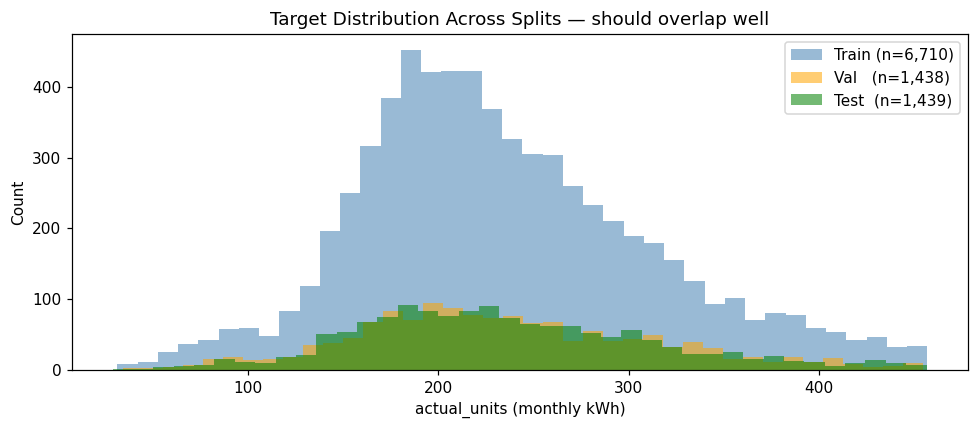

Train target mean: 234.2  std: 77.5
Val   target mean: 235.5  std: 78.8
Test  target mean: 235.5  std: 77.9


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 3 · Train / Validation / Test Split + Scaling
# ─────────────────────────────────────────────────────────────
# Split strategy:
#   70% Train  — model learns from this
#   15% Val    — hyperparameter tuning uses this (never seen by tuner as test)
#   15% Test   — final holdout, touched only once at the end
#
# Scaling:
#   StandardScaler fitted on X_train ONLY.
#   X_val and X_test are transformed (not re-fit) to prevent
#   any information from val/test leaking into the scaler parameters.

X = df[ALL_FEATURES]
y = df[TARGET]

# 70 / 30 split first
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

# 50 / 50 of the 30% → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Val   : {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%)')
print()

# ── Scale continuous features ──────────────────────────────────
scaler = StandardScaler()

X_train_sc = X_train.copy()
X_val_sc   = X_val.copy()
X_test_sc  = X_test.copy()

X_train_sc[SCALE_FEATURES] = scaler.fit_transform(X_train[SCALE_FEATURES])
X_val_sc[SCALE_FEATURES]   = scaler.transform(X_val[SCALE_FEATURES])
X_test_sc[SCALE_FEATURES]  = scaler.transform(X_test[SCALE_FEATURES])

# Verify scaler fitted only on train
print(f'Scaler mean (hist_avg_units): {scaler.mean_[0]:.2f}  '
      f'(should be ~train mean = {y_train.mean():.0f} range)')
print(f'Scaled train hist_avg mean  : {X_train_sc["hist_avg_units"].mean():.4f}  (should be ~0)')
print(f'Scaled train hist_avg std   : {X_train_sc["hist_avg_units"].std():.4f}   (should be ~1)')
print()

# Save scaler and split indices for Team 3 (deployment)
joblib.dump(scaler, 'scaler_team2.pkl')
np.save('test_indices.npy', X_test.index.values)
print('scaler_team2.pkl saved.')
print('test_indices.npy saved.')

# ── Verify target distribution is similar across splits ────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_train, bins=40, alpha=0.55, label=f'Train (n={len(y_train):,})', color='steelblue')
ax.hist(y_val,   bins=40, alpha=0.55, label=f'Val   (n={len(y_val):,})',   color='orange')
ax.hist(y_test,  bins=40, alpha=0.55, label=f'Test  (n={len(y_test):,})',  color='green')
ax.set_xlabel('actual_units (monthly kWh)')
ax.set_ylabel('Count')
ax.set_title('Target Distribution Across Splits — should overlap well')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Train target mean: {y_train.mean():.1f}  std: {y_train.std():.1f}')
print(f'Val   target mean: {y_val.mean():.1f}  std: {y_val.std():.1f}')
print(f'Test  target mean: {y_test.mean():.1f}  std: {y_test.std():.1f}')

---
## MEMBER B - Baseline Models

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 4 · Helper — Evaluate Any Regression Model
# ─────────────────────────────────────────────────────────────
# Single reusable function so all models are compared fairly.
# Prints Train/Val metrics side by side to detect overfitting.

results_log = []  # accumulate all model results

def evaluate_model(name, model, X_tr, y_tr, X_vl, y_vl, store=True):
    """
    Fit model on X_tr / y_tr, evaluate on both train and val.
    Returns dict of metrics. Optionally appends to results_log.
    """
    if "XGB" in model.__class__.__name__:
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            verbose=False
        )
    else:
        model.fit(X_tr, y_tr)

    y_tr_pred = model.predict(X_tr)
    y_vl_pred = model.predict(X_vl)

    train_r2  = r2_score(y_tr, y_tr_pred)
    val_r2    = r2_score(y_vl, y_vl_pred)
    train_mae = mean_absolute_error(y_tr, y_tr_pred)
    val_mae   = mean_absolute_error(y_vl, y_vl_pred)
    train_rmse= np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    val_rmse  = np.sqrt(mean_squared_error(y_vl, y_vl_pred))

    overfit_gap = train_r2 - val_r2
    overfit_flag = '⚠️ OVERFIT' if overfit_gap > 0.10 else 'NO'

    row = {
        'Model': name,
        'Train R²': round(train_r2, 4),
        'Val R²':   round(val_r2,   4),
        'Train MAE': round(train_mae, 2),
        'Val MAE':   round(val_mae,   2),
        'Train RMSE': round(train_rmse, 2),
        'Val RMSE':   round(val_rmse,   2),
        'Overfit?': overfit_flag
    }

    print(f'  {name:<28}  Train R²={train_r2:.4f}  Val R²={val_r2:.4f}  '
          f'Val MAE={val_mae:.2f}  {overfit_flag}')

    if store:
        results_log.append(row)

    return model, row

print('evaluate_model() helper defined.')

evaluate_model() helper defined.


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 5 · Baseline Models — Linear, Ridge, Lasso, Random Forest
# ─────────────────────────────────────────────────────────────
# Why these baselines?
#   Linear Regression — simplest possible model; sets the floor.
#   Ridge             — linear + L2 regularisation (handles multicollinearity).
#   Lasso             — linear + L1 regularisation (performs feature selection).
#   Random Forest     — ensemble of trees; strong non-linear baseline.
#   These four tell us how much XGBoost actually improves over simpler methods.

print('Running baseline models...\n')

# 1. Linear Regression
lr_model, lr_res = evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train_sc, y_train, X_val_sc, y_val
)

# 2. Ridge (alpha tuned by intuition; formal tuning in Cell 7)
ridge_model, ridge_res = evaluate_model(
    'Ridge (alpha=10)',
    Ridge(alpha=10, random_state=RANDOM_STATE),
    X_train_sc, y_train, X_val_sc, y_val
)

# 3. Lasso
lasso_model, lasso_res = evaluate_model(
    'Lasso (alpha=0.1)',
    Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000),
    X_train_sc, y_train, X_val_sc, y_val
)

# 4. Random Forest (shallow for speed; tuned version later)
rf_model, rf_res = evaluate_model(
    'Random Forest (100 trees)',
    RandomForestRegressor(
        n_estimators=100, max_depth=12,
        min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train_sc, y_train, X_val_sc, y_val
)
print()
print('Baseline Summary:')
display(pd.DataFrame(results_log))

Running baseline models...

  Linear Regression             Train R²=0.7345  Val R²=0.7437  Val MAE=32.96  NO
  Ridge (alpha=10)              Train R²=0.7344  Val R²=0.7435  Val MAE=32.97  NO
  Lasso (alpha=0.1)             Train R²=0.7341  Val R²=0.7429  Val MAE=33.01  NO
  Random Forest (100 trees)     Train R²=0.9429  Val R²=0.8795  Val MAE=20.66  NO

Baseline Summary:


,Model,Train R²,Val R²,Train MAE,Val MAE,Train RMSE,Val RMSE,Overfit?
0,Linear Regression,0.7345,0.7437,32.40,32.96,39.94,39.88,NO
1,Ridge (alpha=10),0.7344,0.7435,32.40,32.97,39.94,39.90,NO
2,Lasso (alpha=0.1),0.7341,0.7429,32.44,33.01,39.96,39.94,NO
3,Random Forest (100 trees),0.9429,0.8795,14.05,20.66,18.52,27.35,NO


In [9]:
print('Running XGBoost...\n')

xgb_base_model, xgb_base_res = evaluate_model(
    'XGBoost',
    xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='mae',
        early_stopping_rounds=20,
        verbosity=0
    ),
    X_train_sc, y_train, X_val_sc, y_val
)

print()
display(pd.DataFrame(results_log))

Running XGBoost...

  XGBoost                       Train R²=0.9677  Val R²=0.9074  Val MAE=17.99  NO



,Model,Train R²,Val R²,Train MAE,Val MAE,Train RMSE,Val RMSE,Overfit?
0,Linear Regression,0.7345,0.7437,32.40,32.96,39.94,39.88,NO
1,Ridge (alpha=10),0.7344,0.7435,32.40,32.97,39.94,39.90,NO
2,Lasso (alpha=0.1),0.7341,0.7429,32.44,33.01,39.96,39.94,NO
3,Random Forest (100 trees),0.9429,0.8795,14.05,20.66,18.52,27.35,NO
4,XGBoost,0.9677,0.9074,10.99,17.99,13.94,23.97,NO


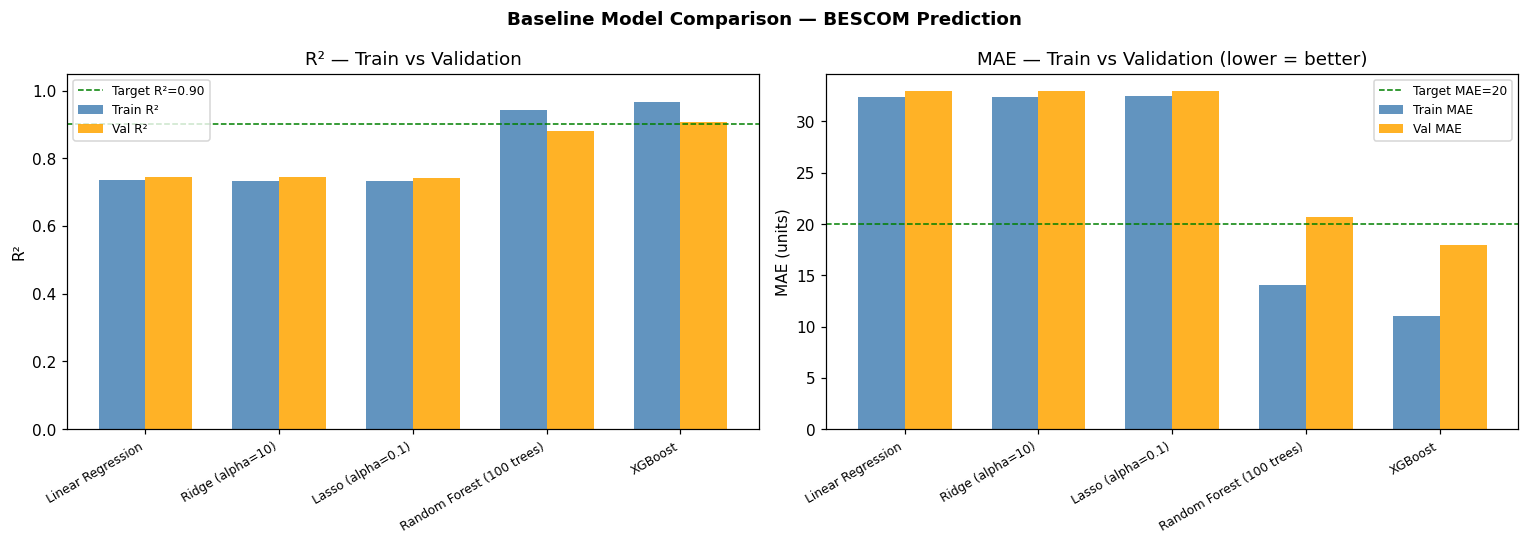

Observation:
  Best Val R²  → XGBoost : 0.9074
  Best Val MAE → XGBoost : 17.99 units


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 6 · Baseline Comparison Plot
# ─────────────────────────────────────────────────────────────
baseline_df = pd.DataFrame(results_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_  = baseline_df['Model']
x_pos    = np.arange(len(models_))
bar_w    = 0.35

# R² comparison
ax = axes[0]
ax.bar(x_pos - bar_w/2, baseline_df['Train R²'], bar_w,
       label='Train R²', color='steelblue', alpha=0.85)
ax.bar(x_pos + bar_w/2, baseline_df['Val R²'],   bar_w,
       label='Val R²',   color='orange',    alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(models_, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('R²')
ax.set_title('R² — Train vs Validation')
ax.axhline(0.90, color='green',  ls='--', lw=1, label='Target R²=0.90')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

# MAE comparison
ax2 = axes[1]
ax2.bar(x_pos - bar_w/2, baseline_df['Train MAE'], bar_w,
        label='Train MAE', color='steelblue', alpha=0.85)
ax2.bar(x_pos + bar_w/2, baseline_df['Val MAE'],   bar_w,
        label='Val MAE',   color='orange',    alpha=0.85)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models_, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('MAE (units)')
ax2.set_title('MAE — Train vs Validation (lower = better)')
ax2.axhline(20, color='green', ls='--', lw=1, label='Target MAE=20')
ax2.legend(fontsize=8)

plt.suptitle('Baseline Model Comparison — BESCOM Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation:')
best_val_r2 = baseline_df.loc[baseline_df['Val R²'].idxmax()]
print(f'  Best Val R²  → {best_val_r2["Model"]} : {best_val_r2["Val R²"]:.4f}')
best_val_mae = baseline_df.loc[baseline_df['Val MAE'].idxmin()]
print(f'  Best Val MAE → {best_val_mae["Model"]} : {best_val_mae["Val MAE"]:.2f} units')

---
## MEMBER C - Hyperparameter Tuning + Cross-Validation

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 7 · Optuna — XGBoost Hyperparameter Tuning
# ─────────────────────────────────────────────────────────────
# Why Optuna over GridSearchCV?
#   Optuna uses Bayesian TPE (Tree-structured Parzen Estimator)
#   which is smarter than exhaustive grid search — it learns which
#   regions of the hyperparameter space work well and focuses there.
#   For XGBoost with 8 hyperparameters, GridSearch would require
#   thousands of fits. Optuna finds a good solution in 50–80 trials.
#
# Objective: minimise Val MAE
# Data: X_train_sc / y_train for fit; X_val_sc / y_val for evaluate
# Test set: NOT touched here — preserved as final holdout.

def xgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators',    100, 800),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'max_depth'         : trial.suggest_int('max_depth',       3, 10),
        'min_child_weight'  : trial.suggest_int('min_child_weight',1, 10),
        'subsample'         : trial.suggest_float('subsample',     0.50, 1.00),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.40, 1.00),
        'gamma'             : trial.suggest_float('gamma',         0.0, 5.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha',     0.0, 5.0),
        'reg_lambda'        : trial.suggest_float('reg_lambda',    0.5, 5.0),
        'random_state'      : RANDOM_STATE,
        'verbosity'         : 0,
        'eval_metric'       : 'mae',
        'early_stopping_rounds': 20,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train_sc, y_train,
        eval_set=[(X_val_sc, y_val)],
        verbose=False
    )
    y_pred_val = model.predict(X_val_sc)
    return mean_absolute_error(y_val, y_pred_val)


print('Starting Optuna XGBoost tuning (75 trials)...')
print('This takes ~3–5 minutes. Please wait.\n')

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(xgb_objective, n_trials=75, show_progress_bar=True)

best_params = study.best_params
print(f'\nBest Val MAE: {study.best_value:.4f} units')
print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<25}: {v}')

Starting Optuna XGBoost tuning (75 trials)...
This takes ~3–5 minutes. Please wait.



  0%|          | 0/75 [00:00<?, ?it/s]


Best Val MAE: 17.5506 units
Best hyperparameters:
  n_estimators             : 733
  learning_rate            : 0.05117666335643335
  max_depth                : 4
  min_child_weight         : 3
  subsample                : 0.9400131173613441
  colsample_bytree         : 0.9987996413583662
  gamma                    : 3.249360433167791
  reg_alpha                : 2.3058837788475612
  reg_lambda               : 3.2081755353994628


  XGBoost (Optuna tuned)        Train R²=0.9512  Val R²=0.9127  Val MAE=17.55  NO

5-Fold Cross-Validation Results (XGBoost tuned):
  R²  per fold : [np.float64(0.9114), np.float64(0.91), np.float64(0.9098), np.float64(0.9126), np.float64(0.9084)]
  R²  mean±std : 0.9104 ± 0.0014
  MAE per fold : [np.float64(17.69), np.float64(17.23), np.float64(17.74), np.float64(17.86), np.float64(17.77)]
  MAE mean±std : 17.66 ± 0.22 units



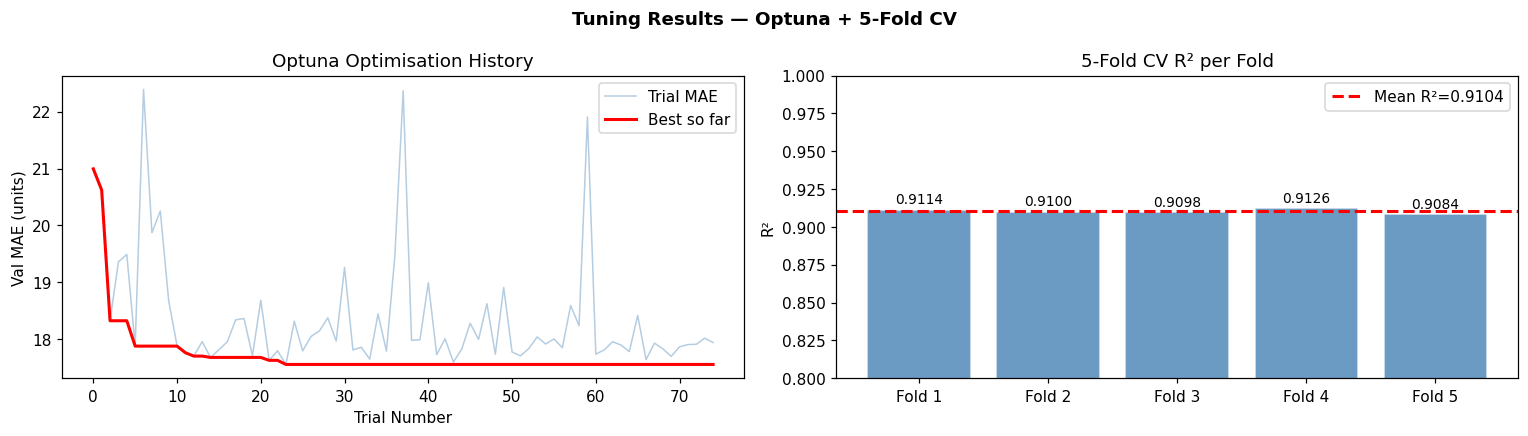

In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 8 · Train Tuned XGBoost + 5-Fold Cross-Validation
# ─────────────────────────────────────────────────────────────
# Step 1: Train final XGBoost with best Optuna params on full train set.
# Step 2: 5-fold CV on (train + val) to get robust R² estimate.
#   CV folds use only train+val — test set never enters CV.

# ── Build tuned model ─────────────────────────────────────────
tuned_params = {
    **best_params,
    'random_state'        : RANDOM_STATE,
    'verbosity'           : 0,
    'eval_metric'         : 'mae',
    'early_stopping_rounds': 20,
}

tuned_xgb = xgb.XGBRegressor(**tuned_params)
tuned_xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=False
)

_, tuned_res = evaluate_model(
    'XGBoost (Optuna tuned)',
    tuned_xgb,
    X_train_sc, y_train, X_val_sc, y_val,
    store=True
)

print()

# ── 5-Fold Cross-Validation on train+val ──────────────────────
# Combine train + val for CV (test stays locked)
X_cv = pd.concat([X_train_sc, X_val_sc], axis=0)
y_cv = pd.concat([y_train,    y_val],    axis=0)

# Use the same tuned params but without early stopping for CV
cv_params = {k: v for k, v in tuned_params.items()
             if k not in ['early_stopping_rounds', 'eval_metric']}
cv_model = xgb.XGBRegressor(**cv_params)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2   = cross_val_score(cv_model, X_cv, y_cv, cv=kf, scoring='r2', n_jobs=-1)
cv_mae  = -cross_val_score(cv_model, X_cv, y_cv, cv=kf,
                            scoring='neg_mean_absolute_error', n_jobs=-1)

print('5-Fold Cross-Validation Results (XGBoost tuned):')
print(f'  R²  per fold : {[round(v,4) for v in cv_r2]}')
print(f'  R²  mean±std : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  MAE per fold : {[round(v,2) for v in cv_mae]}')
print(f'  MAE mean±std : {cv_mae.mean():.2f} ± {cv_mae.std():.2f} units')
print()

# ── Optuna optimisation history plot ──────────────────────────
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(trials_df['number'], trials_df['value'], alpha=0.4,
        color='steelblue', lw=1, label='Trial MAE')
running_best = trials_df['value'].cummin()
ax.plot(trials_df['number'], running_best, color='red', lw=2, label='Best so far')
ax.set_xlabel('Trial Number')
ax.set_ylabel('Val MAE (units)')
ax.set_title('Optuna Optimisation History')
ax.legend()

ax2 = axes[1]
cv_fold_labels = [f'Fold {i+1}' for i in range(5)]
bars = ax2.bar(cv_fold_labels, cv_r2, color='steelblue', alpha=0.8, edgecolor='white')
ax2.axhline(cv_r2.mean(), color='red', ls='--', lw=2, label=f'Mean R²={cv_r2.mean():.4f}')
ax2.set_ylim(0.80, 1.00)
ax2.set_ylabel('R²')
ax2.set_title('5-Fold CV R² per Fold')
ax2.legend()
for bar, val in zip(bars, cv_r2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Tuning Results — Optuna + 5-Fold CV', fontweight='bold')
plt.tight_layout()
plt.show()

  FINAL HOLDOUT TEST SET RESULTS
  Test R²   : 0.9159
  Test MAE  : 17.56 units
  Test RMSE : 22.57 units
  Val  R²   : 0.9127  (for comparison)
  Gap (Val-Test R²): 0.0032  ✅ Good generalisation


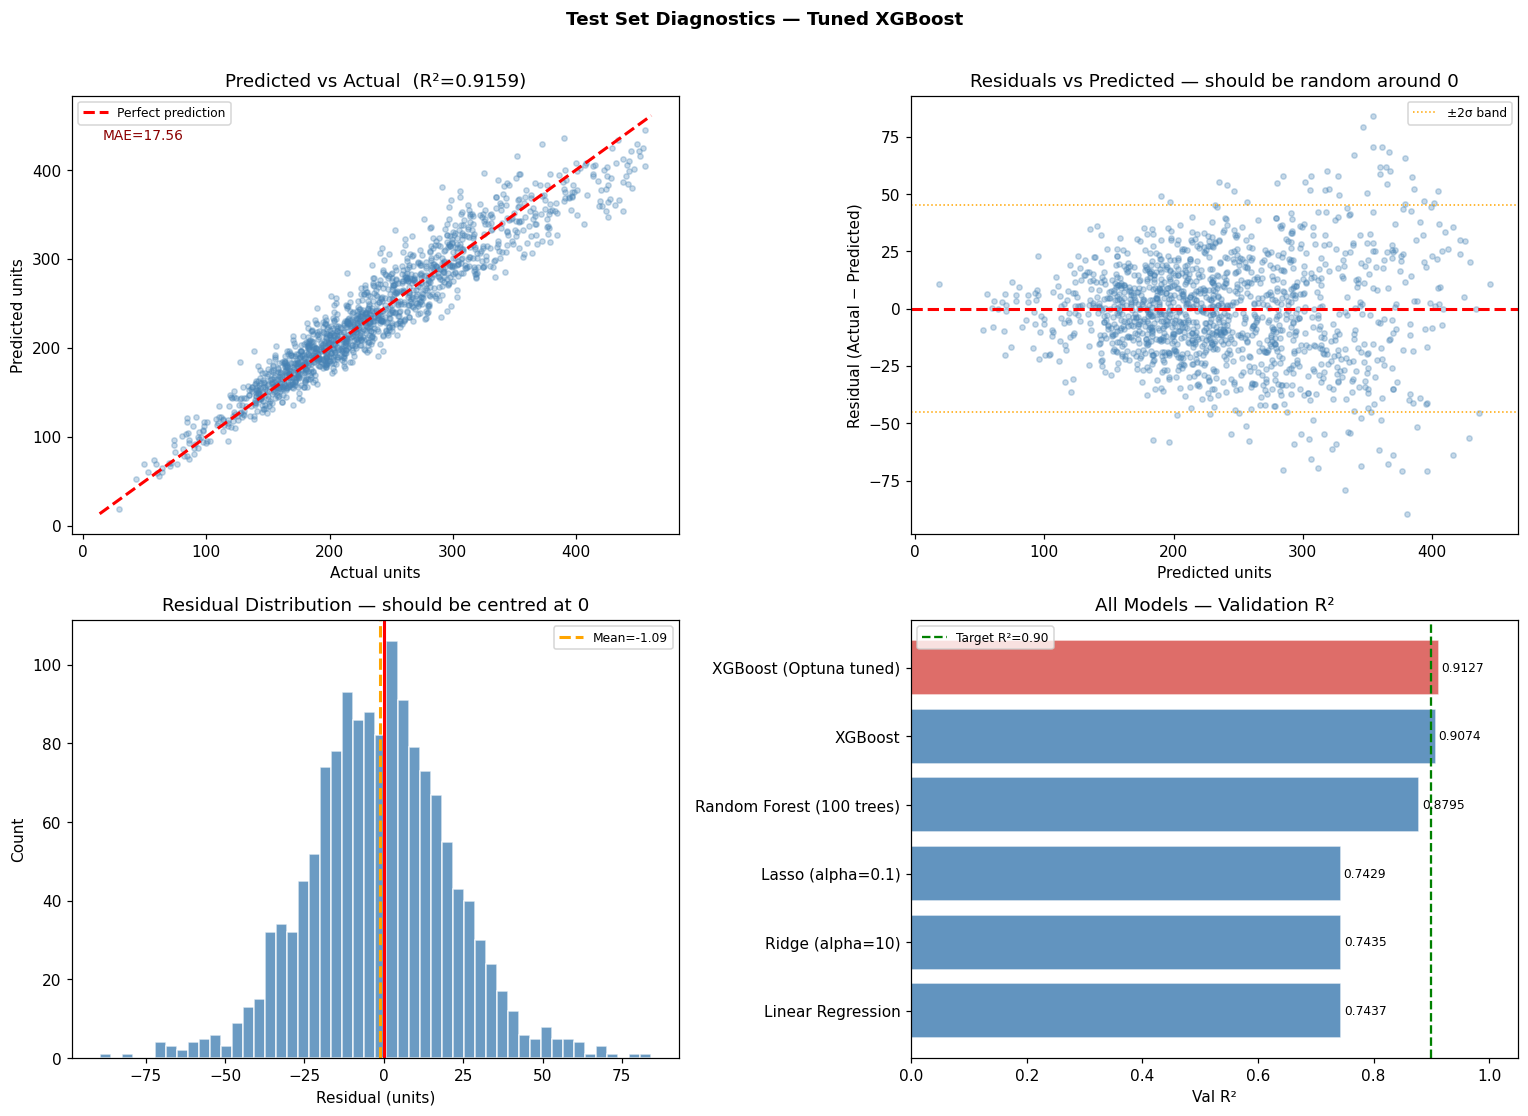

In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 9 · Final Holdout Test Evaluation + Residual Analysis
# ─────────────────────────────────────────────────────────────
# This is the ONE TIME we evaluate on the test set.
# If this number is close to val R² — the model generalises well.
# If it is much lower — we overfit to the validation set during tuning.

y_test_pred = tuned_xgb.predict(X_test_sc)

test_r2   = r2_score(y_test, y_test_pred)
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
residuals = y_test.values - y_test_pred

print('=' * 55)
print('  FINAL HOLDOUT TEST SET RESULTS')
print('=' * 55)
print(f'  Test R²   : {test_r2:.4f}')
print(f'  Test MAE  : {test_mae:.2f} units')
print(f'  Test RMSE : {test_rmse:.2f} units')
print(f'  Val  R²   : {tuned_res["Val R²"]}  (for comparison)')
generalisation_gap = abs(tuned_res['Val R²'] - test_r2)
print(f'  Gap (Val-Test R²): {generalisation_gap:.4f}  '
      + ('✅ Good generalisation' if generalisation_gap < 0.02 else '⚠️ Check for tuning overfit'))
print('=' * 55)

# ── 4-panel diagnostic plot ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y_test, y_test_pred, alpha=0.3, s=12, color='steelblue')
lims = [min(y_test.min(), y_test_pred.min()) - 5,
        max(y_test.max(), y_test_pred.max()) + 5]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual units')
ax.set_ylabel('Predicted units')
ax.set_title(f'Predicted vs Actual  (R²={test_r2:.4f})')
ax.legend(fontsize=8)
ax.text(0.05, 0.90, f'MAE={test_mae:.2f}',
        transform=ax.transAxes, fontsize=9, color='darkred')

# Panel 2: Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(y_test_pred, residuals, alpha=0.3, s=12, color='steelblue')
ax.axhline(0, color='red', lw=2, ls='--')
ax.axhline( 2*residuals.std(), color='orange', ls=':', lw=1)
ax.axhline(-2*residuals.std(), color='orange', ls=':', lw=1,
           label='±2σ band')
ax.set_xlabel('Predicted units')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted — should be random around 0')
ax.legend(fontsize=8)

# Panel 3: Residual histogram
ax = axes[1, 0]
ax.hist(residuals, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', lw=2)
ax.axvline(residuals.mean(), color='orange', lw=2, ls='--',
           label=f'Mean={residuals.mean():.2f}')
ax.set_xlabel('Residual (units)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution — should be centred at 0')
ax.legend(fontsize=8)

# Panel 4: All models Val R² comparison (updated)
ax = axes[1, 1]
all_results_df = pd.DataFrame(results_log)
colors_bar = ['#d9534f' if 'Optuna' in m else 'steelblue'
              for m in all_results_df['Model']]
bars = ax.barh(all_results_df['Model'], all_results_df['Val R²'],
               color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(0.90, color='green', ls='--', lw=1.5, label='Target R²=0.90')
ax.set_xlabel('Val R²')
ax.set_title('All Models — Validation R²')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, all_results_df['Val R²']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Test Set Diagnostics — Tuned XGBoost', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
##  MEMBER D - SHAP Explainability + Final Export + Recommendation Engine

SHAP computed on 1,439 test samples.

Top-10 features by mean |SHAP|:


,mean |SHAP|
hist_avg_units,30.386000
month_sin,19.381001
days_home,18.079000
baseload_kwh,17.125999
month_cos,15.521000
total_hca_kwh,9.253000
num_people,7.236000
has_any_ac,3.429000
geyser_kwh,2.992000
microwave_kwh,2.507000


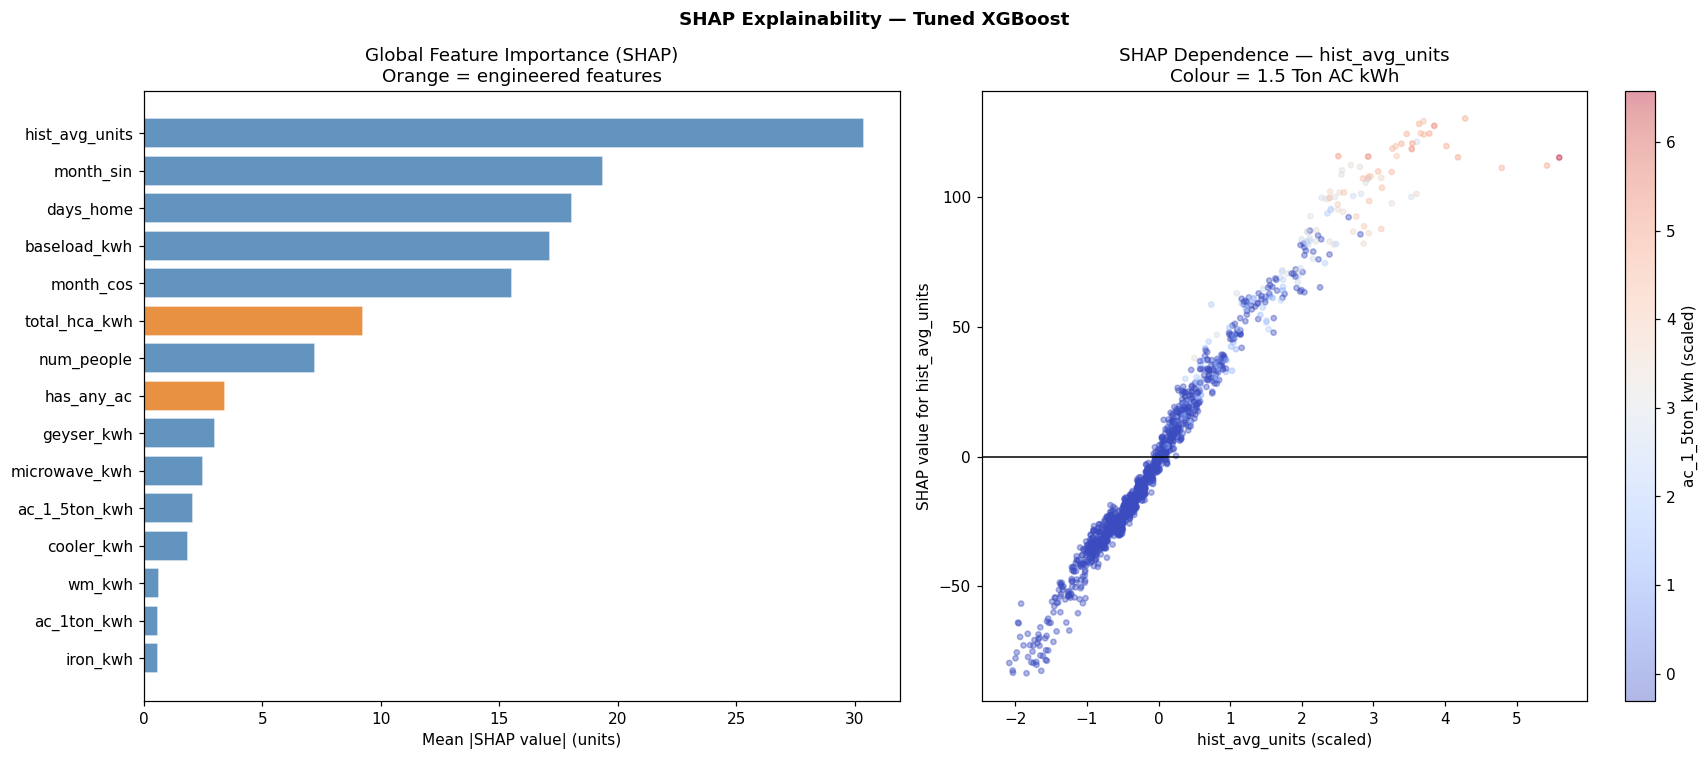

In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 10 · SHAP Feature Importance
# ─────────────────────────────────────────────────────────────
# SHAP (SHapley Additive exPlanations) explains EACH prediction.
# For each row: SHAP value for feature X = how many units that
# feature pushed the prediction up or down from the mean.
#
# Why this matters for the mentor:
#   • Proves the model learned physics — AC features dominate in summer
#   • Identifies which appliance to recommend reducing
#   • Makes the black-box model explainable to non-technical users

# Use TreeExplainer (fast, exact for tree models)
explainer  = shap.TreeExplainer(tuned_xgb)
shap_vals  = explainer.shap_values(X_test_sc)  # shape: (n_test, n_features)

shap_df = pd.DataFrame(shap_vals, columns=ALL_FEATURES)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print(f'SHAP computed on {len(X_test_sc):,} test samples.')
print('\nTop-10 features by mean |SHAP|:')
display(mean_abs_shap.head(10).to_frame('mean |SHAP|').round(3))

# ── SHAP Summary (Beeswarm) Plot ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar plot — global importance
ax = axes[0]
top_features = mean_abs_shap.head(15)
colors_shap  = ['#e67e22' if f in {'has_any_ac','has_ac_1ton','has_ac_1_5ton',
                                    'total_hca_kwh','partial_month','high_occupancy'}
                else 'steelblue' for f in top_features.index]
ax.barh(top_features.index[::-1], top_features.values[::-1],
        color=colors_shap[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (units)')
ax.set_title('Global Feature Importance (SHAP)\nOrange = engineered features')

# SHAP dependence for hist_avg_units (most important)
ax2 = axes[1]
feat = 'hist_avg_units'
feat_idx = list(ALL_FEATURES).index(feat)
sc = ax2.scatter(
    X_test_sc[feat],
    shap_df[feat],
    c=X_test_sc['ac_1_5ton_kwh'],
    cmap='coolwarm', alpha=0.4, s=12
)
plt.colorbar(sc, ax=ax2, label='ac_1_5ton_kwh (scaled)')
ax2.axhline(0, color='black', lw=1)
ax2.set_xlabel(f'{feat} (scaled)')
ax2.set_ylabel(f'SHAP value for {feat}')
ax2.set_title('SHAP Dependence — hist_avg_units\n'
              'Colour = 1.5 Ton AC kWh')

plt.suptitle('SHAP Explainability — Tuned XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

Example household:
  Actual units    : 226.3
  Predicted units : 218.6
  Error           : -7.7 units

Top SHAP contributions for this household:


,Feature,SHAP value,Feature value (scaled)
21,total_hca_kwh,-16.237,-0.730
0,hist_avg_units,-13.815,-0.101
6,baseload_kwh,12.235,0.552
5,month_cos,-4.855,1.201
3,days_home,4.566,0.356
4,month_sin,4.232,-0.689
9,geyser_kwh,-3.263,-0.588
2,num_people,2.350,0.233
22,has_any_ac,1.979,0.000
1,hist_trend,1.748,-0.574


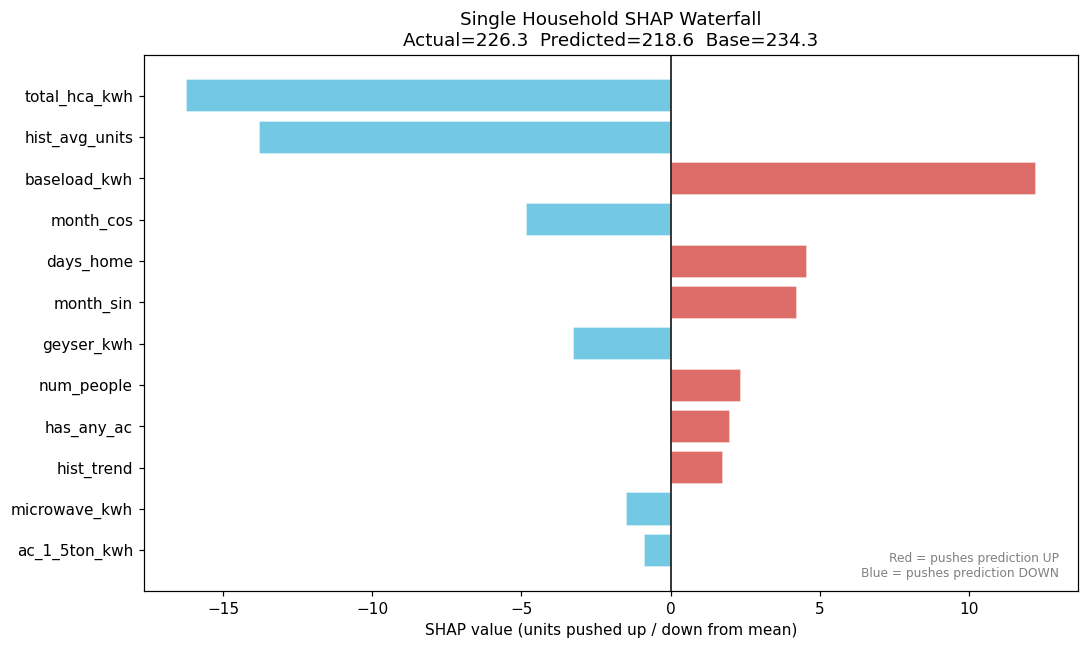


This waterfall shows the mentor EXACTLY why the model predicted
that number — not a black box.


In [27]:
# ─────────────────────────────────────────────────────────────
# CELL 11 · SHAP Waterfall for a Single Prediction
# ─────────────────────────────────────────────────────────────
# Pick one test household and show exactly WHY the model predicted
# that number — which features pushed it up / down.
# This is what the recommendation engine will use per user.

# Pick the household closest to median actual_units
median_actual = np.median(y_test.values)
sample_idx_in_test = np.argmin(np.abs(y_test.values - median_actual))

sample_row   = X_test_sc.iloc[[sample_idx_in_test]]
sample_actual = y_test.values[sample_idx_in_test]
sample_pred   = tuned_xgb.predict(sample_row)[0]
sample_shap   = shap_vals[sample_idx_in_test]

print(f'Example household:')
print(f'  Actual units    : {sample_actual:.1f}')
print(f'  Predicted units : {sample_pred:.1f}')
print(f'  Error           : {sample_pred - sample_actual:.1f} units')
print()

# Top contributing features for this household
sample_shap_df = pd.DataFrame({
    'Feature'   : ALL_FEATURES,
    'SHAP value': sample_shap,
    'Feature value (scaled)': sample_row.values[0]
}).sort_values('SHAP value', key=abs, ascending=False).head(12)

print('Top SHAP contributions for this household:')
display(sample_shap_df.round(3))

# Waterfall-style bar chart
fig, ax = plt.subplots(figsize=(10, 6))

top12 = sample_shap_df.head(12).iloc[::-1]
colors_wf = ['#d9534f' if v > 0 else '#5bc0de' for v in top12['SHAP value']]
ax.barh(top12['Feature'], top12['SHAP value'],
        color=colors_wf, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('SHAP value (units pushed up / down from mean)')
ax.set_title(f'Single Household SHAP Waterfall\n'
             f'Actual={sample_actual:.1f}  Predicted={sample_pred:.1f}  '
             f'Base={explainer.expected_value:.1f}')
ax.text(0.98, 0.02, 'Red = pushes prediction UP\nBlue = pushes prediction DOWN',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print()
print('This waterfall shows the mentor EXACTLY why the model predicted')
print('that number — not a black box.')

In [15]:
# CELL 12 · Final Summary Table + Model + Recommendation Engine
# PART A: Final comparison table across ALL models
final_df = pd.DataFrame(results_log)
print('=' * 70)
print('  FINAL MODEL COMPARISON')
print('=' * 70)
display(final_df.style.highlight_max(subset=['Val R²'], color='lightgreen')
                      .highlight_min(subset=['Val MAE'], color='lightgreen'))
print()
print(f'  Selected model : XGBoost (Optuna tuned)')
print(f'  Test R²        : {test_r2:.4f}')
print(f'  Test MAE       : {test_mae:.2f} units')
print(f'  Test RMSE      : {test_rmse:.2f} units')
print(f'  5-Fold CV R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

# ─────────────────────────────────────────────────────────────
# PART B: Save model and scaler
# ─────────────────────────────────────────────────────────────
joblib.dump(tuned_xgb,   'model_xgb_tuned.pkl')
joblib.dump(scaler,      'scaler_team2.pkl')

# Save SHAP explainer for deployment
joblib.dump(explainer, 'shap_explainer.pkl')

# Save feature list (Team 3 must use exactly this order)
with open('feature_order.json', 'w') as f:
    json.dump(ALL_FEATURES, f, indent=2)

print()
print('Files saved:')
print('  model_xgb_tuned.pkl    — trained XGBoost model')
print('  scaler_team2.pkl       — StandardScaler (fit on train only)')
print('  shap_explainer.pkl     — SHAP TreeExplainer')
print('  feature_order.json     — exact feature column order for inference')

# ─────────────────────────────────────────────────────────────
# PART C: Recommendation Engine (stub for Team 3)
# ─────────────────────────────────────────────────────────────
# This function takes a user's input dict, runs the model,
# and returns a personalised recommendation.

def predict_and_recommend(
    user_input: dict,
    model_path: str = 'model_xgb_tuned.pkl',
    scaler_path: str = 'scaler_team2.pkl',
    feature_path: str = 'feature_order.json'
):
    """
    Parameters
    ----------
    user_input : dict with keys matching ALL_FEATURES.
        Example:
        {
            'hist_avg_units': 185.0,
            'hist_trend'    : 10.0,
            'num_people'    : 3,
            'days_home'     : 30,
            'month_sin'     : 0.5,
            'month_cos'     : 0.866,
            'baseload_kwh'  : 120.0,
            'ac_1ton_kwh'   : 0.0,
            'ac_1_5ton_kwh' : 270.0,
            'geyser_kwh'    : 30.0,
            'wm_kwh'        : 10.0,
            'microwave_kwh' : 18.0,
            'cooler_kwh'    : 0.0,
            'iron_kwh'      : 6.5,
            'has_ac_1ton'   : 0,
            'has_ac_1_5ton' : 1,
            'has_geyser'    : 1,
            'has_wm'        : 1,
            'has_microwave' : 1,
            'has_cooler'    : 0,
            'has_iron'      : 1,
            'total_hca_kwh' : 334.5,
            'has_any_ac'    : 1,
            'high_occupancy': 0,
            'partial_month' : 0,
        }

    Returns
    -------
    dict with predicted_units, entitlement_limit, status, recommendations
    """
    import joblib, json
    import pandas as pd
    import numpy as np

    model   = joblib.load(model_path)
    scaler  = joblib.load(scaler_path)
    with open(feature_path) as fh:
        feature_order = json.load(fh)

    BINARY_COLS = [
        'has_ac_1ton', 'has_ac_1_5ton', 'has_geyser',
        'has_wm', 'has_microwave', 'has_cooler', 'has_iron',
        'has_any_ac', 'high_occupancy', 'partial_month'
    ]
    scale_cols = [c for c in feature_order if c not in BINARY_COLS]

    # Build input DataFrame in correct column order
    row = pd.DataFrame([user_input])[feature_order]
    row[scale_cols] = scaler.transform(row[scale_cols])

    predicted_units = float(model.predict(row)[0])

    # Entitlement is recalculated here from hist_avg_units at inference time.
    # NOTE for Team 3: entitlement_limit was intentionally excluded from the
    # training features because it is directly derived from hist_avg_units
    # (= min(hist_avg × 1.10, 200)), making it redundant as a model input.
    # It is only computed here — at inference — for the slab engine to decide
    # whether to charge the household ₹0, partial, or the full BESCOM tariff.
    hist_avg         = user_input['hist_avg_units']
    entitlement      = min(hist_avg * 1.10, 200)
    units_over       = max(0, predicted_units - entitlement)
    pct_over         = (units_over / entitlement) * 100 if entitlement > 0 else 0
    hist_avg         = user_input['hist_avg_units']
    entitlement      = min(hist_avg * 1.10, 200)
    units_over       = max(0, predicted_units - entitlement)
    pct_over         = (units_over / entitlement) * 100 if entitlement > 0 else 0

    if units_over <= 0:
        status = 'SAFE — within entitlement, bill = ₹0'
    elif predicted_units <= 200:
        status = f'PARTIAL — {units_over:.1f} units over entitlement, partial bill applies'
    else:
        status = f'ABOVE 200 — full BESCOM formula applies'
        
    # Identify top appliance to cut (by kWh column — biggest mover)
    hca_map = {
        'ac_1ton_kwh'    : '1 Ton AC',
        'ac_1_5ton_kwh'  : '1.5 Ton AC',
        'geyser_kwh'     : 'Geyser',
        'wm_kwh'         : 'Washing Machine',
        'microwave_kwh'  : 'Microwave',
        'cooler_kwh'     : 'Air Cooler',
        'iron_kwh'       : 'Iron'
    }
    appliance_kwh = {
        name: user_input.get(col, 0)
        for col, name in hca_map.items()
    }
    top_appliance = max(appliance_kwh, key=appliance_kwh.get)
    top_kwh       = appliance_kwh[top_appliance]

    recommendations = []
    if units_over > 0:
        saving_needed = units_over + 5  # small buffer
        recommendations.append(
            f'Reduce {top_appliance} usage by ~{saving_needed:.0f} units '
            f'(currently {top_kwh:.1f} kWh/month, ~{top_kwh/30:.1f} kWh/day)'
        )
        if user_input.get('has_geyser', 0) == 1 and user_input.get('geyser_kwh', 0) > 15:
            recommendations.append(
                'Set geyser timer to 20 min/day — saves ~6 units/month'
            )
        if user_input.get('has_ac_1_5ton', 0) == 1:
            recommendations.append(
                'Set AC temperature to 24°C (BEE recommendation) — saves ~8% AC energy'
            )

    return {
        'predicted_units'   : round(predicted_units, 1),
        'entitlement_limit' : round(entitlement, 1),
        'units_over'        : round(units_over, 1),
        'status'            : status,
        'recommendations'   : recommendations
    }


# ── Demo run ──────────────────────────────────────────────────
demo_input = {
    'hist_avg_units': 185.0,
    'hist_trend'    : 10.0,
    'num_people'    : 3,
    'days_home'     : 30,
    'month_sin'     : 0.5,    # April
    'month_cos'     : 0.866,
    'baseload_kwh'  : 120.0,
    'ac_1ton_kwh'   : 0.0,
    'ac_1_5ton_kwh' : 270.0,  # 1.5T AC, 6hrs/day, April
    'geyser_kwh'    : 30.0,
    'wm_kwh'        : 10.0,
    'microwave_kwh' : 18.0,
    'cooler_kwh'    : 0.0,
    'iron_kwh'      : 6.5,
    'has_ac_1ton'   : 0,
    'has_ac_1_5ton' : 1,
    'has_geyser'    : 1,
    'has_wm'        : 1,
    'has_microwave' : 1,
    'has_cooler'    : 0,
    'has_iron'      : 1,
    'total_hca_kwh' : 334.5,
    'has_any_ac'    : 1,
    'high_occupancy': 0,
    'partial_month' : 0,
}

result = predict_and_recommend(demo_input)

print('\n' + '=' * 55)
print('  RECOMMENDATION ENGINE — DEMO OUTPUT')
print('=' * 55)
print(f'  Predicted units : {result["predicted_units"]} kWh')
print(f'  Entitlement     : {result["entitlement_limit"]} units')
print(f'  Units over      : {result["units_over"]}')
print(f'  Status          : {result["status"]}')
print()
if result['recommendations']:
    print('  Recommendations:')
    for i, r in enumerate(result['recommendations'], 1):
        print(f'    {i}. {r}')
else:
    print('  No action needed — you are within your free entitlement!')
print('=' * 55)

  FINAL MODEL COMPARISON


,Model,Train R²,Val R²,Train MAE,Val MAE,Train RMSE,Val RMSE,Overfit?
0,Linear Regression,0.734500,0.743700,32.400000,32.960000,39.940000,39.880000,NO
1,Ridge (alpha=10),0.734400,0.743500,32.400000,32.970000,39.940000,39.900000,NO
2,Lasso (alpha=0.1),0.734100,0.742900,32.440000,33.010000,39.960000,39.940000,NO
3,Random Forest (100 trees),0.942900,0.879500,14.050000,20.660000,18.520000,27.350000,NO
4,XGBoost,0.967700,0.907400,10.990000,17.990000,13.940000,23.970000,NO
5,XGBoost (Optuna tuned),0.951200,0.912700,13.460000,17.550000,17.130000,23.280000,NO



  Selected model : XGBoost (Optuna tuned)
  Test R²        : 0.9159
  Test MAE       : 17.56 units
  Test RMSE      : 22.57 units
  5-Fold CV R²   : 0.9104 ± 0.0014

Files saved:
  model_xgb_tuned.pkl    — trained XGBoost model
  scaler_team2.pkl       — StandardScaler (fit on train only)
  shap_explainer.pkl     — SHAP TreeExplainer
  feature_order.json     — exact feature column order for inference

  RECOMMENDATION ENGINE — DEMO OUTPUT
  Predicted units : 208.4 kWh
  Entitlement     : 200 units
  Units over      : 8.4
  Status          : ABOVE 200 — full BESCOM formula applies

  Recommendations:
    1. Reduce 1.5 Ton AC usage by ~13 units (currently 270.0 kWh/month, ~9.0 kWh/day)
    2. Set geyser timer to 20 min/day — saves ~6 units/month
    3. Set AC temperature to 24°C (BEE recommendation) — saves ~8% AC energy
